In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
train_dir = path + "/brain_tumor_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#training
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 519ms/step - accuracy: 0.5764 - loss: 1.0801 - val_accuracy: 0.7600 - val_loss: 0.5483
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step - accuracy: 0.8177 - loss: 0.4857 - val_accuracy: 0.7600 - val_loss: 0.5387
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 414ms/step - accuracy: 0.8571 - loss: 0.3620 - val_accuracy: 0.8000 - val_loss: 0.5022
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 460ms/step - accuracy: 0.9360 - loss: 0.2116 - val_accuracy: 0.8600 - val_loss: 0.4779
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step - accuracy: 0.9507 - loss: 0.1403 - val_accuracy: 0.8800 - val_loss: 0.4733
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 488ms/step - accuracy: 0.9704 - loss: 0.0768 - val_accuracy: 0.9000 - val_loss: 0.4742
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 395ms/step - accuracy: 1.0000 - loss: 0.0280 - val_accuracy: 0.8800 - val_loss: 0.5338
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 487ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 0.

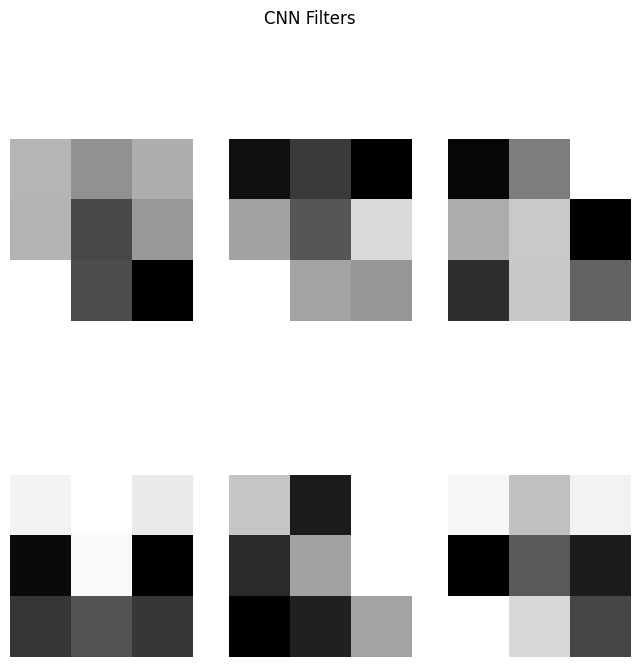

In [ ]:
#filter visualization
filters, biases = model.layers[0].get_weights()

plt.figure(figsize=(8,8))

for i in range(6):
    f = filters[:,:,:,i]
    plt.subplot(2,3,i+1)
    plt.imshow(f[:,:,0], cmap='gray')
    plt.axis('off')

plt.suptitle("CNN Filters")
plt.show()

In [ ]:
#evaluation
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.8800 - loss: 0.5359
Validation Accuracy: 0.8799999952316284
Validation Loss: 0.5358838438987732


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

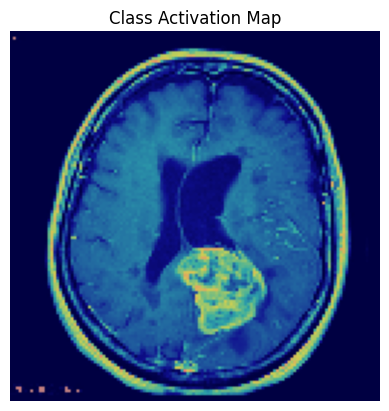

In [ ]:
import cv2

img = train_data[0][0][0]

heatmap = np.mean(img, axis=-1)

plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Class Activation Map")
plt.axis('off')